<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Exploratory Data Analysis**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis or EDA. 


## Objectives


In this lab, you will perform the following:


- Examine the structure of a dataset.

- Handle missing values effectively.

- Conduct summary statistics on key columns.

- Analyze employment status, job satisfaction, programming language usage, and trends in remote work.


## Hands on Lab


#### Step 1: Install and Import Libraries


Install the necessary libraries for data manipulation and visualization.


In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 183.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 191.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 157.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 154.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 154.3 MB/s eta 0:00:00


In [4]:
!pip install numpy

#### Step 2: Load and Preview the Dataset
Load the dataset from the provided URL. Use df.head() to display the first few rows to get an overview of the structure.


In [5]:
# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)
# Set pandas option to display all columns
pd.set_option('display.max_columns', None)
# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I have never visited Stack Overflow or the Sta...,NaN,NaN,NaN,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,NaN,NaN,NaN,NaN,NaN,NaN,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,NaN,NaN,NaN,Microsoft Teams;Slack,Slack,Slack,NaN,NaN,NaN,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Individual contributor,17.0,Agree,Disagree,Agree,Agree,Agree,Neither agree nor disa

In [6]:
df.duplicated().sum()

np.int64(0)

#### Step 3: Handling Missing Data


Identify and manage missing values in critical columns such as `Employment`, `JobSat`, and `RemoteWork`. Implement a strategy to fill or drop these values, depending on the significance of the missing data.


In [7]:
## Write your code here
df['Employment'].isnull().sum()

np.int64(0)

In [8]:
df['JobSat'].isnull().sum()

np.int64(36311)

In [9]:
mean_jbst = int(df['JobSat'].mean()) # Finding mean 'JobSat'
print(mean_jbst)

6


In [10]:
df['JobSat'] = df['JobSat'].fillna(mean_jbst)

In [11]:
df['JobSat'].isnull().sum()

np.int64(0)

In [12]:
df['RemoteWork'].isnull().sum()

np.int64(10631)

In [13]:
mode_rmwk = df['RemoteWork'].mode()[0]
print(mode_rmwk)

Hybrid (some remote, some in-person)


In [14]:
df['RemoteWork'] = df['RemoteWork'].fillna(mode_rmwk)

In [15]:
df['RemoteWork'].isnull().sum()

np.int64(0)

#### Step 4: Analysis of Experience and Job Satisfaction


Analyze the relationship between years of professional coding experience (`YearsCodePro`) and job satisfaction (`JobSat`). Summarize `YearsCodePro` and calculate median satisfaction scores based on experience ranges.

- Create experience ranges for `YearsCodePro` (e.g., `0-5`, `5-10`, `10-20`, `>20` years).

- Calculate the median `JobSat` for each range.

- Visualize the relationship using a bar plot or similar visualization.


In [16]:
# Example data cleaning steps (a# Example data cleaning steps (adjust as needed for your specific dataset format)
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Remove rows with missing values for the relevant columns
df.dropna(subset=['YearsCodePro', 'JobSat'], inplace=True)

In [17]:
# Define the bins and labels
bins = [0, 5, 10, 20, 50] # Adjust the upper bound based on data max
labels = ['0-5 years', '5-10 years', '10-20 years', '>20 years']

# Create a new column for the experience ranges
df['ExperienceRange'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels, right=False)

# Calculate the median JobSat for each range
median_jobsat_by_range = df.groupby('ExperienceRange')['JobSat'].median().reindex(labels)

print(median_jobsat_by_range)

ExperienceRange
0-5 years      6.0
5-10 years     6.0
10-20 years    6.0
>20 years      6.0
Name: JobSat, dtype: float64


/tmp/ipykernel_300/3841796758.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_jobsat_by_range = df.groupby('ExperienceRange')['JobSat'].median().reindex(labels)


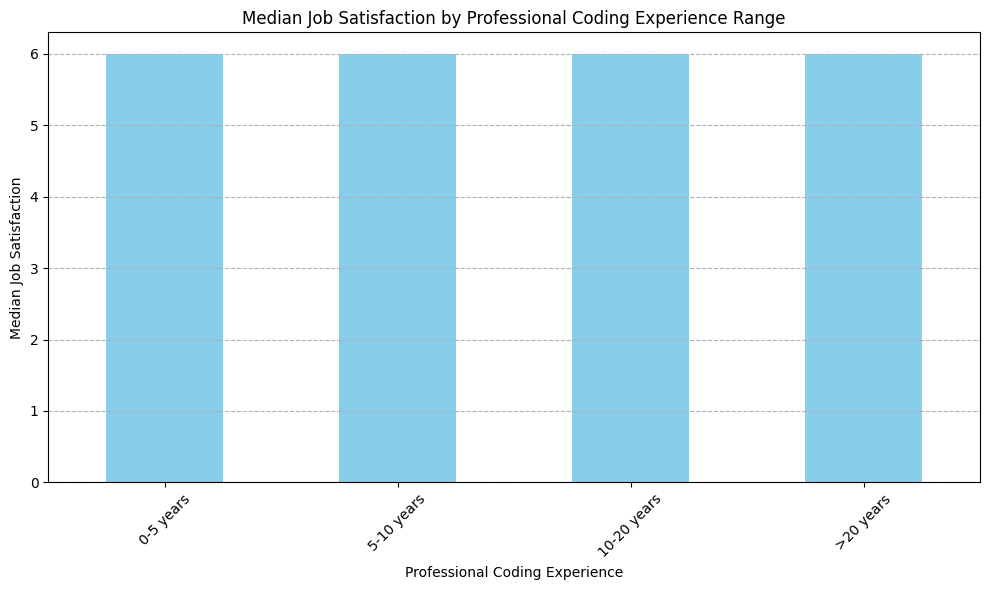

In [18]:
# Create the bar plot
plt.figure(figsize=(10, 6))
median_jobsat_by_range.plot(kind='bar', color='skyblue')
plt.title('Median Job Satisfaction by Professional Coding Experience Range')
plt.xlabel('Professional Coding Experience')
plt.ylabel('Median Job Satisfaction')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [19]:
## Write your code here
df[['YearsCodePro', 'JobSat']].head(2)

,YearsCodePro,JobSat
1,17.0,6.0
2,27.0,6.0


In [20]:
df['YearsCodePro'].isnull().sum()

np.int64(0)

In [21]:
mode_yrcdpro = df['YearsCodePro'].mode()[0]
print(mode_yrcdpro)

2.0


In [22]:
df['YearsCodePro'] = df['YearsCodePro'].fillna(mode_yrcdpro)

In [23]:
df['YearsCodePro'].isnull().sum()

np.int64(0)

In [24]:
# Assuming df is your DataFrame
#df['YearsCodePro'] = df['YearsCodePro'].replace('Less than 1 year', 1)
#df['YearsCodePro'] = df['YearsCodePro'].replace('More than 50 years', 50)

In [25]:
#df['YearsCodePro'].astype(float)

In [26]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

In [27]:
# 0-5, 5-10, 10-20, 20+ years // # Assume 'df' is your DataFrame and 'YearsCodePro' is a column in it
# --- Define your experience thresholds --- 
# Example categories (adjust as needed for your data)
bins = [0, 5, 10, 20, float('inf')] 
labels = ['Entry-Level', 'Mid-Level', 'Senior', 'Expert']
# --- Method 1: Using pd.cut (Recommended for numerical ranges) ---
# This is cleaner for defining bins and labels
df['ExperienceLevel'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels, right=False) 


In [28]:
new_df = df[['YearsCodePro', 'ExperienceLevel', 'JobSat']]
new_df.head()

,YearsCodePro,ExperienceLevel,JobSat
1,17.0,Senior,6.0
2,27.0,Expert,6.0
6,7.0,Mid-Level,6.0
9,11.0,Senior,6.0
11,25.0,Expert,6.0


In [29]:
median_jobsat_by_exp_lvl = new_df.groupby('ExperienceLevel', observed=True)['JobSat'].median()
median_jobsat_by_exp_lvl.head()

ExperienceLevel
Entry-Level    6.0
Mid-Level      6.0
Senior         6.0
Expert         6.0
Name: JobSat, dtype: float64

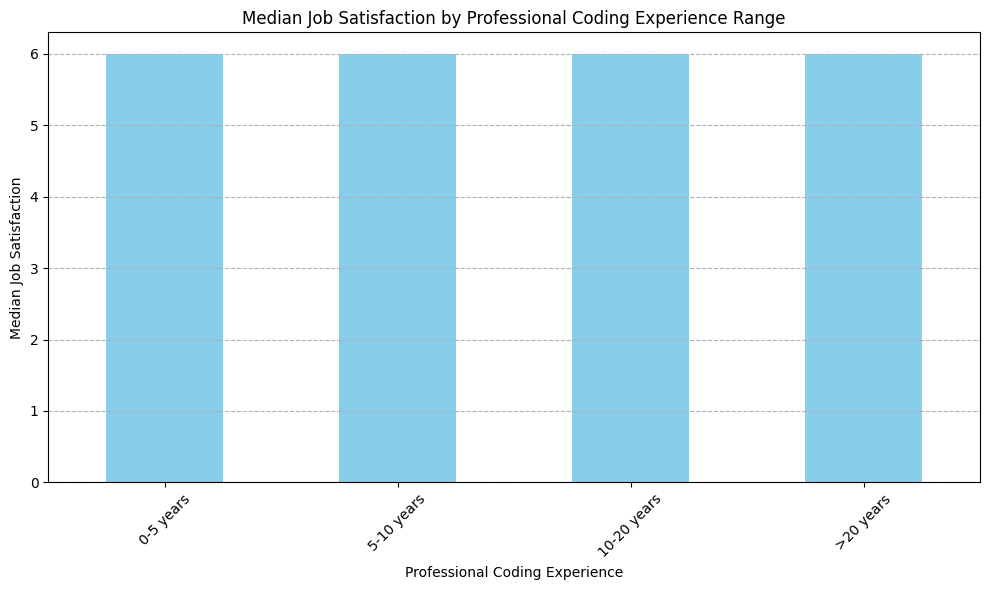

In [30]:
# Create the bar plot
plt.figure(figsize=(10, 6))
median_jobsat_by_range.plot(kind='bar', color='skyblue')
plt.title('Median Job Satisfaction by Professional Coding Experience Range')
plt.xlabel('Professional Coding Experience')
plt.ylabel('Median Job Satisfaction')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

#### Step 5: Visualize Job Satisfaction


Use a count plot to show the distribution of `JobSat` values. This provides insights into the overall satisfaction levels of respondents.


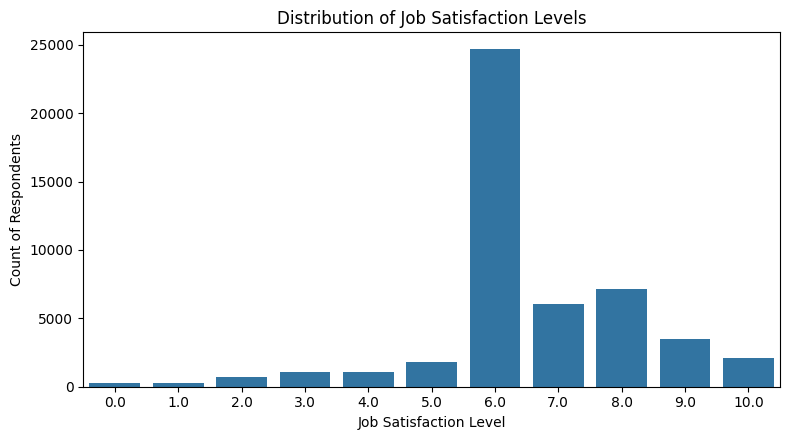

In [31]:
## Write your code here
plt.figure(figsize=(8, 4.5))
sns.countplot(data=new_df, x='JobSat')
# Add title and labels
plt.title('Distribution of Job Satisfaction Levels')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Count of Respondents')
#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlapping
# Display the plot
plt.tight_layout() # Adjust layout to make room for rotated labels
plt.show()

#### Step 6: Analyzing Remote Work Preferences by Job Role


Analyze trends in remote work based on job roles. Use the `RemoteWork` and `Employment` columns to explore preferences and examine if specific job roles prefer remote work more than others.

- Use a count plot to show remote work distribution.

- Cross-tabulate remote work preferences by employment type (e.g., full-time, part-time) and job roles.


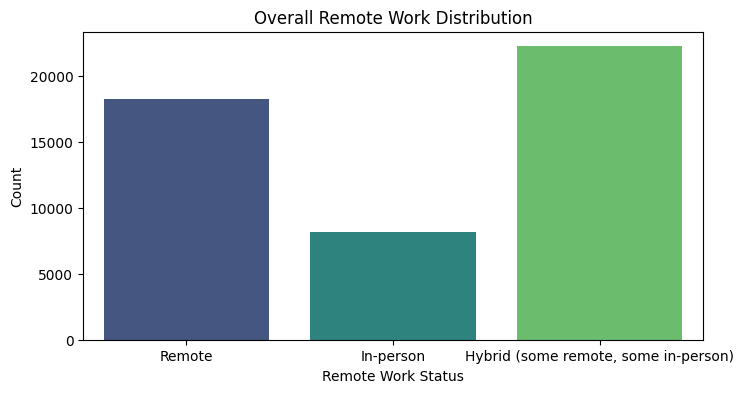

In [32]:
## Write your code here
# Assume df is your DataFrame with 'RemoteWork', 'Employment', 'JobRole' columns

# 1. Create a Count Plot for Remote Work Distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='RemoteWork', hue='RemoteWork' , palette='viridis')
plt.title('Overall Remote Work Distribution')
plt.xlabel('Remote Work Status')
plt.ylabel('Count')
plt.show()

In [33]:
df['Employment'] = df['Employment'].str.strip()

In [34]:
df['Employment'] = df['Employment'].str.lower()

In [35]:
df['Employment'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

1                                        employed fulltime
2                                        employed fulltime
6                                        employed fulltime
9        independent contractor freelancer or selfemployed
11                                       employed fulltime
                               ...                        
65428                                    employed fulltime
65431                                    employed fulltime
65432                                    employed fulltime
65434                                    employed fulltime
65435                                    employed fulltime
Name: Employment, Length: 48704, dtype: object

In [36]:
df['Employment'].isnull().sum()

np.int64(0)

In [37]:
df.dropna(subset=['Employment'], inplace=True)

In [38]:
mapping = {
    'ft': 'full-time',
    'full time': 'full-time',
    'perm': 'full-time',
    'pt': 'part-time',
    'contractor': 'contract'
}
df['Employment'] = df['Employment'].replace(mapping)

In [39]:
short_names = {
    'employed, full-time': 'FT',
    'employed, part-time': 'PT',
    'independent contractor, freelancer, or self-employed': 'Contract',
    'employed, full-time;independent contractor, freelancer, or self-employed' : 'FT Contract',
    'student, full-time;not employed, but looking for work;employed, part-time' : 'ST, FT-LW, PT',
    'student, full-time;not employed, but looking for work;not employed, and not looking for work' : 'ST, NE-LW, NE-NLW',
    'student, full-time;not employed, but looking for work;retired' : 'ST, FT-LW, R',
    'student, full-time;student, part-time;retired' : 'ST, FT, PT, R',
    'student, part-time;retired' : 'ST, PT, R',
    'not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time;retired' : 'NE, LW, Contract, PT, R',
    'not employed, but looking for work;retired' : 'NE, LW, R',
    'student, full-time;independent contractor, freelancer, or self-employed;employed, part-time;retired': 'ST, FT, Contract, PT, R',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time;employed, part-time;retired ' : 'ST, FT, PT, LW, Contract, R',
    'not employed, but looking for work': 'Searching',
    'employed, full-time;student, full-time;independent contractor, freelancer, or self-employed;student, part-time;retired' : 'E, FT, ST, Contractor, PT, R',
    'not employed, but looking for work;not employed, and not looking for work;student, part-time;employed, part-time' : 'NE, LW, NE, NLW, ST, PT, EM, PT',
    'not employed, but looking for work;independent contractor, freelancer, or self-employed;not employed, and not looking for work;retired' : 'NE, NLW, R',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time;employed, part-time;retired' : 'ST, FT, NE, LW, Contractor, PT, E, PT',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;employed, part-time' : 'ST, FT, NE, LW, Contractor, PT',
    'student, full-time;not employed, but looking for work;student, part-time' : 'ST, FT; NE, LW; ST, PT',
    'student, full-time;student, part-time' : 'ST,FT;ST,PT',
    'student, full-time;student, part-time;employed, part-time' : 'ST,FT;ST,PT;E,PT',
    'student, part-time' : 'ST,PT',
    'student, part-time;employed, part-time' : 'ST,PT;E,PT',
    'student, full-time;independent contractor, freelancer, or self-employed;student, part-time;employed, part-time' : 'ST,FT;Contractor;ST,PT;E,PT',
    'student, full-time;not employed, and not looking for work' : 'ST,FT;NE,NLW',
    'student, full-time;not employed, but looking for work' : 'ST,FT;NE,LW',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed' : 'ST,FT;NE,LW;Contractor',
    'student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;student, part-time' : 'ST,FT;NE,LW;Contractor;ST,PT',
    'employed, full-time;student, full-time;not employed, but looking for work;student, part-time;employed, part-time' : 'E,FT; ST,FT; NE,LW; ST,PT; E,PT',
    'employed, full-time;student, full-time;not employed, but looking for work;independent contractor, freelancer, or self-employed;employed, part-time' : 'E,FT;ST,FT;NE,LW;Contract;E,PT',
    'employed, full-time;independent contractor, freelancer, or self-employed;not employed, and not looking for work' : 'E,FT;Contractor;NE,NLW',
    'employed, full-time;independent contractor, freelancer, or self-employed;retired' : 'E,FT;Contractor;SE,R',
    'employed, full-time;not employed, but looking for work;not employed, and not looking for work;employed, part-time' : 'E,FT;NE,LW;NE,NLW;E,PT'
}

In [40]:
df['Employment'] = df['Employment'].replace(short_names) # Replaces only the specified values; others remain unchanged

In [41]:
df['Employment'] = df['Employment'].astype('category')

In [42]:
df['Employment'].value_counts()

Employment
FT                                                                                                                                33841
Contract                                                                                                                           4015
FT Contract                                                                                                                        3199
Searching                                                                                                                          1158
PT                                                                                                                                  899
                                                                                                                                  ...  
NE, NLW, R                                                                                                                            1
employed, full-time;student, full-tim

In [43]:
df['MainBranch'].value_counts()

MainBranch
I am a developer by profession                                                           44111
I am not primarily a developer, but I write code sometimes as part of my work/studies     4593
Name: count, dtype: int64

In [44]:
# 2. Cross-Tabulation: Remote Work by Job Role , Job Role column unavailable in the dataset
# Shows counts of each preference within specific roles
pd.crosstab(df['MainBranch'], df['RemoteWork'])


RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
MainBranch,,,
I am a developer by profession,19708,7221,17182
"I am not primarily a developer, but I write code sometimes as part of my work/studies",2553,991,1049


In [45]:
df['RemoteWork'] = df['RemoteWork'].replace('Hybrid (some remote, some in-person)', 'Hybrid')

In [46]:

# 3. Cross-Tabulation: Remote Work by Employment Type
# Shows counts for full-time, part-time, etc.
pd.crosstab(df['Employment'], df['RemoteWork'])

RemoteWork,Hybrid,In-person,Remote
Employment,,,
Contract,1040,203,2772
"E, FT, ST, Contractor, PT, R",1,0,0
"E,FT; ST,FT; NE,LW; ST,PT; E,PT",1,0,0
"E,FT;Contractor;NE,NLW",0,1,0
"E,FT;Contractor;SE,R",0,1,0
...,...,...,...
"student, full-time;employed, part-time",354,166,153
"student, full-time;independent contractor, freelancer, or self-employed",69,15,120
"student, full-time;independent contractor, freelancer, or self-employed;employed, part-time",52,4,35


In [47]:
multi_agg = pd.crosstab(
    index=df['Employment'],
    columns=df['RemoteWork'],
    values=df['MainBranch'],
    aggfunc=['count']
)
print(multi_agg['count'])

RemoteWork                                          Hybrid  In-person  Remote
Employment                                                                   
Contract                                              1040        203    2772
E, FT, ST, Contractor, PT, R                             1          0       0
E,FT; ST,FT; NE,LW; ST,PT; E,PT                          1          0       0
E,FT;Contractor;NE,NLW                                   0          1       0
E,FT;Contractor;SE,R                                     0          1       0
...                                                    ...        ...     ...
student, full-time;employed, part-time                 354        166     153
student, full-time;independent contractor, free...      69         15     120
student, full-time;independent contractor, free...      52          4      35
student, full-time;independent contractor, free...       3          0       2
student, full-time;independent contractor, free...       2      

In [48]:
# Creating the pivot table
pivot = df.pivot_table(
    index='MainBranch',        # Vertical row labels
    columns='Employment',      # Horizontal column headers
    values='RemoteWork',       # The data being summarized
    aggfunc='count',           # How to summarize (e.g., 'count', 'mean', 'sum')
    fill_value=0 ,             # Replace missing combinations with 0
    observed=True
)
print(pivot)

Employment                                          Contract  \
MainBranch                                                     
I am a developer by profession                          3658   
I am not primarily a developer, but I write cod...       357   

Employment                                          E, FT, ST, Contractor, PT, R  \
MainBranch                                                                         
I am a developer by profession                                                 0   
I am not primarily a developer, but I write cod...                             1   

Employment                                          E,FT; ST,FT; NE,LW; ST,PT; E,PT  \
MainBranch                                                                            
I am a developer by profession                                                    1   
I am not primarily a developer, but I write cod...                                0   

Employment                                          E,FT;

#### Step 7: Analyzing Programming Language Trends by Region


Analyze the popularity of programming languages by region. Use the `LanguageHaveWorkedWith` column to investigate which languages are most used in different regions.

- Filter data by country or region.

- Visualize the top programming languages by region with a bar plot or heatmap.


In [49]:
## Write your code here
df[['Country', 'LanguageHaveWorkedWith']].head()

,Country,LanguageHaveWorkedWith
1,United Kingdom of Great Britain and Northern I...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...
2,United Kingdom of Great Britain and Northern I...,C#
6,United States of America,R
9,Serbia,HTML/CSS;JavaScript;TypeScript
11,Poland,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Power...


In [50]:
# Function to process and count languages
def count_languages_by_country(df_filtered):
    # Split the semicolon-separated strings and stack the results
    language_series = df_filtered['LanguageHaveWorkedWith'].str.split(';').explode()
    # Count the occurrences of each language
    return language_series.value_counts()

# Count languages for all regions combined (as a baseline)
# all_regions_language_counts = count_languages_by_country(df_regional)

In [51]:
# Filter for specific countries
df_us = df[df['Country'] == 'United States of America']
df_india = df[df['Country'] == 'India']

# Get top languages for each country
top_languages_us = count_languages_by_country(df_us).head(10)
top_languages_india = count_languages_by_country(df_india).head(10)

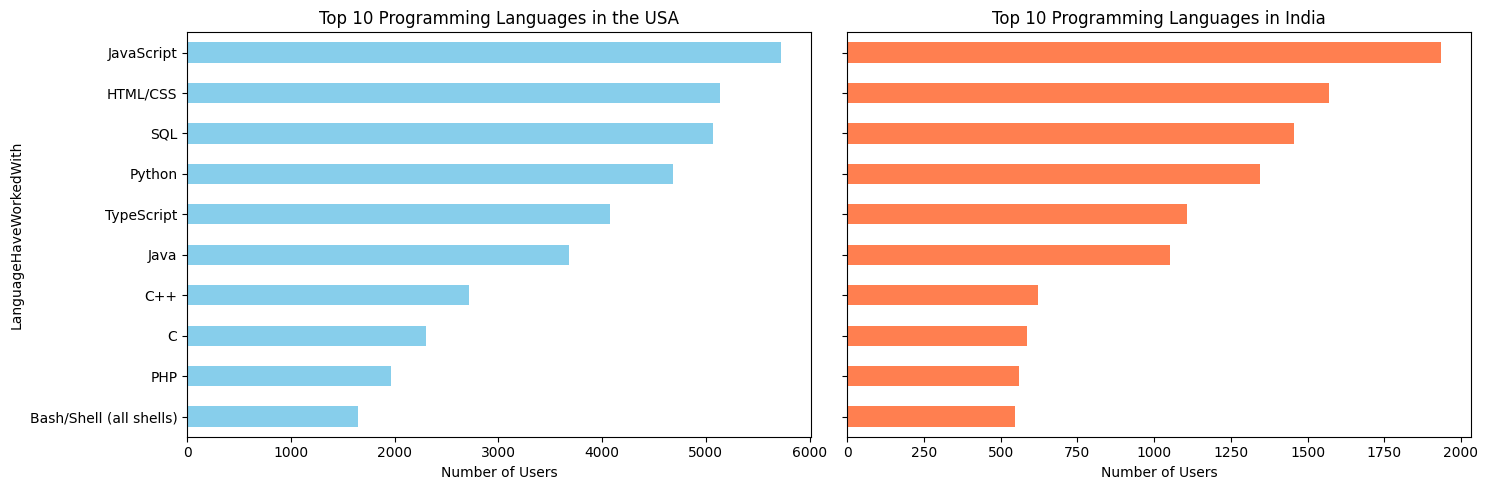

In [52]:
# Create subplots for comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Bar plot for the United States
top_languages_us.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Programming Languages in the USA')
axes[0].set_xlabel('Number of Users')
axes[0].invert_yaxis() # Invert for better readability

# Bar plot for India
top_languages_india.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Programming Languages in India')
axes[1].set_xlabel('Number of Users')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### Step 8: Correlation Between Experience and Satisfaction


Examine how years of experience (`YearsCodePro`) correlate with job satisfaction (`JobSatPoints_1`). Use a scatter plot to visualize this relationship.


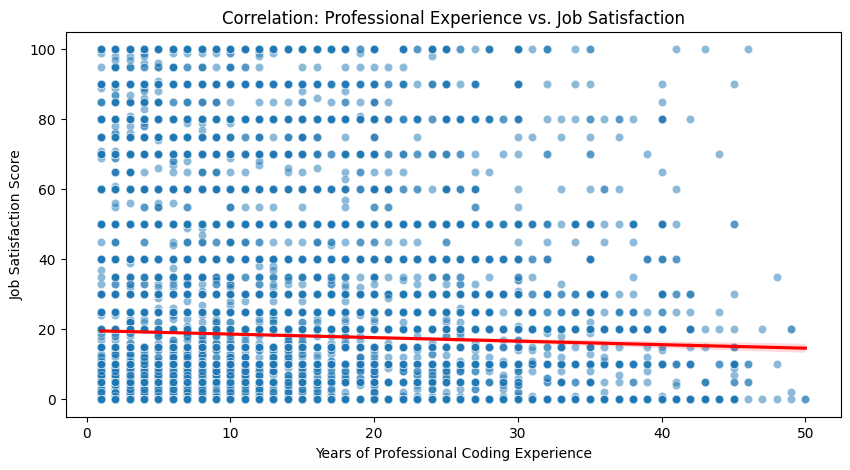

In [53]:
# Create the scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='YearsCodePro', y='JobSatPoints_1', alpha=0.5)
# Optional: Add a regression line to better visualize the trend
sns.regplot(data=df, x='YearsCodePro', y='JobSatPoints_1', scatter=False, color='red')
plt.title('Correlation: Professional Experience vs. Job Satisfaction')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Job Satisfaction Score')
plt.show()

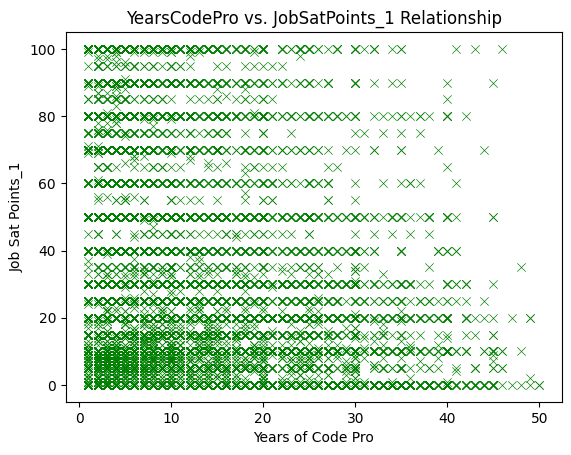

In [54]:
# Create the scatter plot
sns.scatterplot(x="YearsCodePro", y="JobSatPoints_1", data=df, color='green', marker='x')

# Add title and labels (optional, using Matplotlib)
plt.title("YearsCodePro vs. JobSatPoints_1 Relationship")
plt.xlabel("Years of Code Pro")
plt.ylabel("Job Sat Points_1")

# Display the plot
plt.show()

#### Step 9: Educational Background and Employment Type


Explore how educational background (`EdLevel`) relates to employment type (`Employment`). Use cross-tabulation and visualizations to understand if higher education correlates with specific employment types.


In [55]:
# Standardization Mapping
mapping = {
    'Primary/elementary school': 'Low',
    'Something else': 'Medium',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'Medium',
    'Some college/university study without earning a degree': 'Medium',
    'Associate degree (A.A., A.S., etc.)': 'Medium',
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 'High',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'High',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'High'
}

# Apply Mapping
df['Education_Standardized'] = df['EdLevel'].map(mapping)
# For ordinals, convert to categorical
df['Education_Standardized'] = pd.Categorical(df['Education_Standardized'], categories=['Low', 'Medium', 'High'], ordered=True)

In [56]:
df['Education_Standardized'].value_counts()

Education_Standardized
High      38217
Medium    10196
Low         291
Name: count, dtype: int64

In [57]:
ct = pd.crosstab(df['Employment'], df['Education_Standardized'], normalize='index')
print(ct)

Education_Standardized                                   Low    Medium  \
Employment                                                               
Contract                                            0.009714  0.268244   
E, FT, ST, Contractor, PT, R                        0.000000  0.000000   
E,FT; ST,FT; NE,LW; ST,PT; E,PT                     0.000000  0.000000   
E,FT;Contractor;NE,NLW                              0.000000  0.000000   
E,FT;Contractor;SE,R                                0.000000  1.000000   
...                                                      ...       ...   
student, full-time;employed, part-time              0.010401  0.494799   
student, full-time;independent contractor, free...  0.029412  0.500000   
student, full-time;independent contractor, free...  0.043956  0.527473   
student, full-time;independent contractor, free...  0.000000  0.600000   
student, full-time;independent contractor, free...  0.000000  1.000000   

Education_Standardized               

In [58]:
## Write your code here
df[['Education_Standardized', 'Employment']].head()

,Education_Standardized,Employment
1,High,FT
2,High,FT
6,High,FT
9,High,Contract
11,High,FT


In [62]:
print(df['RemoteWork'].value_counts(normalize=True))

RemoteWork
Hybrid       0.457067
Remote       0.374322
In-person    0.168610
Name: proportion, dtype: float64


In [64]:
print(df.groupby('RemoteWork')['YearsCode'].value_counts(normalize=True))

RemoteWork  YearsCode       
Hybrid      10                  0.088898
            8                   0.060929
            7                   0.060524
            6                   0.055713
            15                  0.053689
                                  ...   
Remote      50                  0.001263
            48                  0.001153
            1                   0.001043
            49                  0.000604
            Less than 1 year    0.000220
Name: proportion, Length: 156, dtype: float64


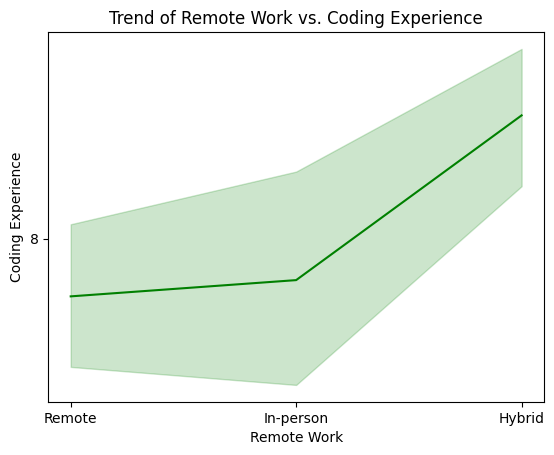

In [65]:
# Create the line plot
sns.lineplot(x="RemoteWork", y="YearsCode", data=df, color='green')

# Add title and labels (optional, using Matplotlib)
plt.title("Trend of Remote Work vs. Coding Experience")
plt.xlabel("Remote Work")
plt.ylabel("Coding Experience")

# Display the plot
plt.show()

In [61]:
# 1. Check distribution of remote work preference
print(df['RemoteWork'].value_counts(normalize=True))

# 2. Analyze remote work by coding experience (e.g., mean years coded)
print(df.groupby('RemoteWork')['YearsCode'].mean())

# 3. Visualize remote work preference (requires matplotlib/seaborn)
import matplotlib.pyplot as plt
df['RemoteWork'].value_counts().plot(kind='bar', title='Remote Work Preference Distribution')
plt.show()


RemoteWork
Hybrid       0.457067
Remote       0.374322
In-person    0.168610
Name: proportion, dtype: float64


TypeError: agg function failed [how->mean,dtype->object]

#### Step 10: Save the Cleaned and Analyzed Dataset


After your analysis, save the modified dataset for further use or sharing.


In [164]:
## Write your code here
df.to_csv('modified_dataset.csv')

<h2>Summary</h2>


In this revised lab, you:

- Loaded and explored the structure of the dataset.

- Handled missing data effectively.

- Analyzed key variables, including working hours, job satisfaction, and remote work trends.

- Investigated programming language usage by region and examined the relationship between experience and satisfaction.

- Used cross-tabulation to understand educational background and employment type.


Copyright © IBM Corporation. All rights reserved.
